In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Numerical and Data Analysis 
import numpy as np 
import pandas as pd 
# Data Visualization 
import seaborn as sns 
import matplotlib.pyplot as plt 
# Extra - To Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('titanic_dataset.csv')

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.shape


(891, 12)

In [8]:
#sibsp- sibling and spouse
#parch - parent + child 
#emabrked -boarding station 


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Missing value check

##### percentage of missing value 
##### identification Mising value 


In [15]:
100*df.isnull().mean()

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [16]:
## cabin column has more than 40% of missing values so straight away droppin it
df1=df.drop("Cabin",axis=1)
#axis =1 as we are dropping the column axis=0 if you want to drop row

In [17]:
100*df1.isnull().mean()

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.224467
dtype: float64

In [19]:
#if mean and median are very far from each other use median, but if mean pr median are close each other use mean
df1["Age"].mean(),df1["Age"].median()

(29.69911764705882, 28.0)

In [21]:
med=100*df1.isnull().mean()
df1["Age"]=df1["Age"].fillna(med)

In [22]:
100*df1.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Embarked       0.224467
dtype: float64

In [29]:
df2=df1[df1["Embarked"].notna()]

In [30]:
100*df2.isnull().mean()

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [31]:
df2.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [35]:
num_cols=["Age","Fare"]
cat_cols=["Survived","Pclass","Sex","Parch","Embarked","SibSp"]
extra_cols=["PassengerId","Name","Ticket"]
len(num_cols)+len(cat_cols)+len(extra_cols)

11

In [36]:
df2.shape


(889, 11)

# univarate analysis 

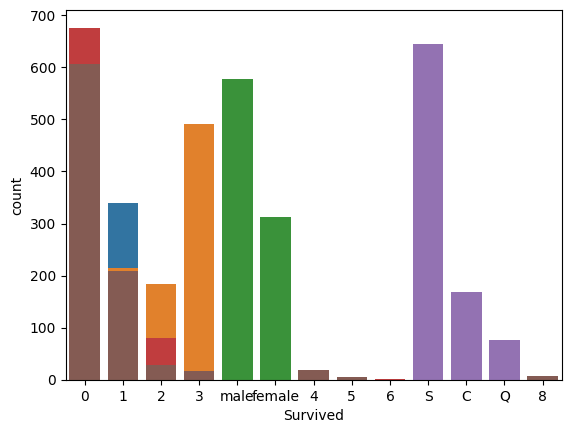

In [39]:
for col in cat_cols:
    sns.countplot(x=df2[col])
    plt.show

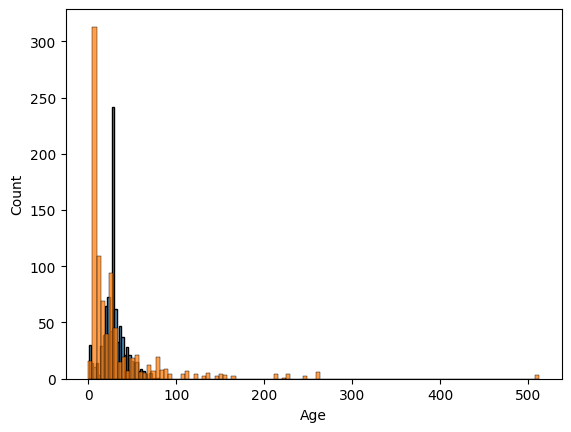

In [43]:
for col in num_cols:
    sns.histplot(x=df2[col])
    plt.show

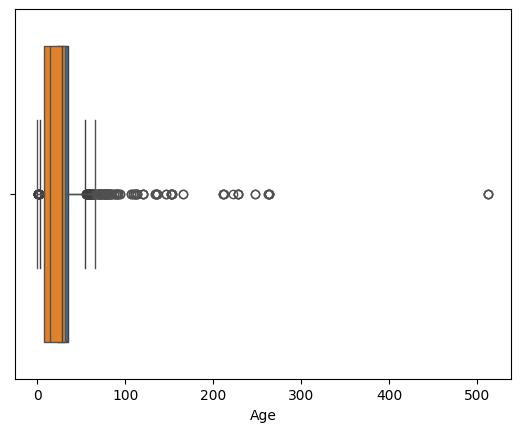

In [42]:
for col in num_cols:
    sns.boxplot(x=df2[col])
    plt.show

In [44]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [45]:
#upper whisker: Q3+1.5*(q3-q1)
#lower whisker: Q1-1.5*(q3-q1)


## Bivariate Analysis 
Numberical vs Numberical

<function matplotlib.pyplot.show(close=None, block=None)>

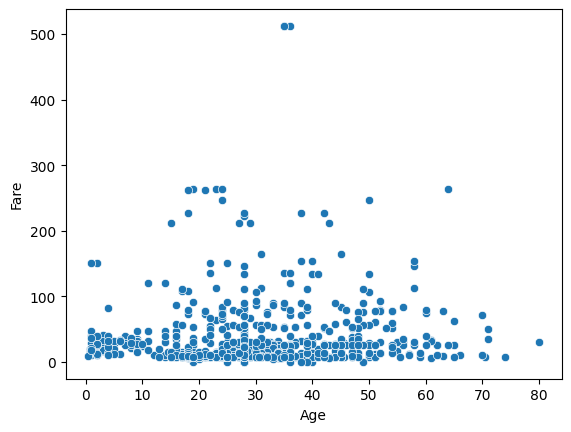

In [48]:
sns.scatterplot(x=df2["Age"],y=df2["Fare"])
plt.show

In [49]:
# Positive Relationship--> if x1 is increasing x2 also increasing 
# Negative Relationships --> if x1 is increasing x2 decreasing 
# No Relationship --> if x1 and x2 have no relationship 

Numberical vs Categorical

<function matplotlib.pyplot.show(close=None, block=None)>

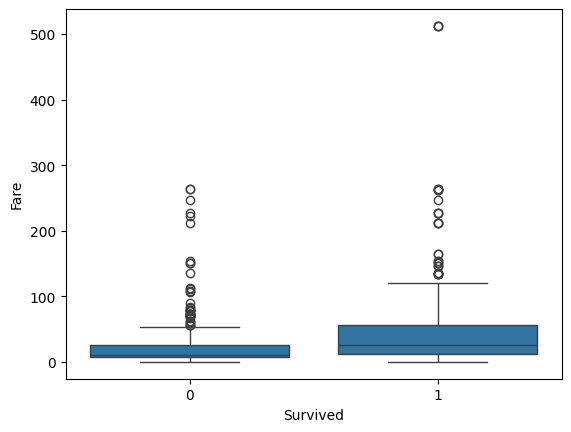

In [51]:
sns.boxplot(x=df2["Survived"],y=df2["Fare"])
plt.show

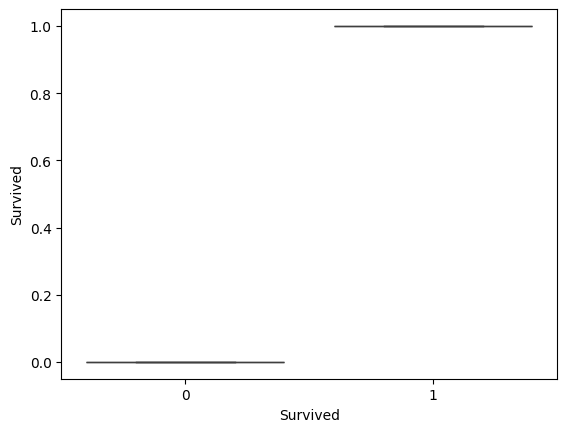

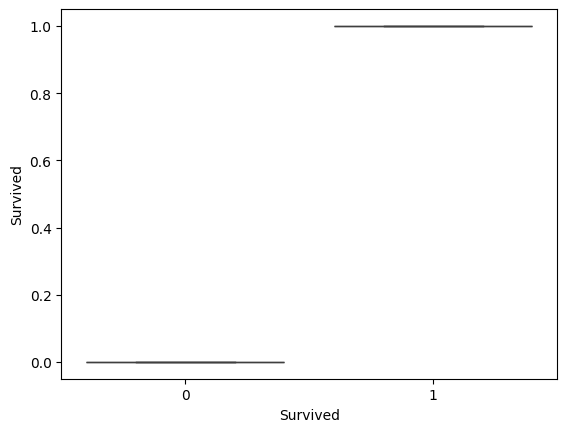

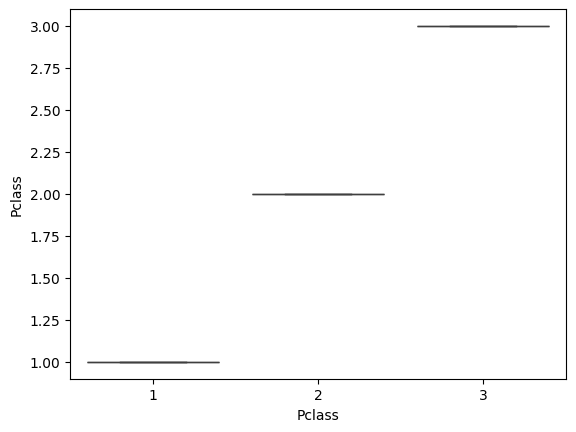

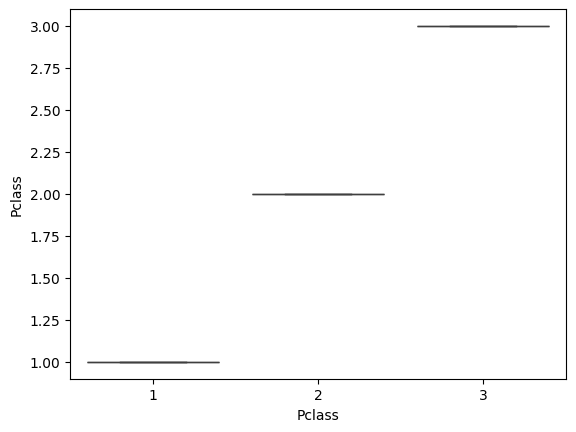

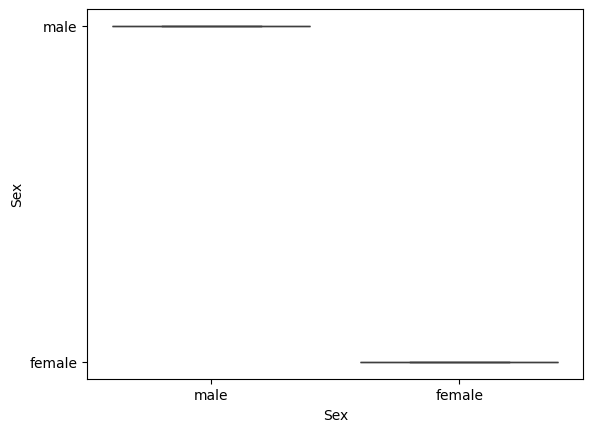

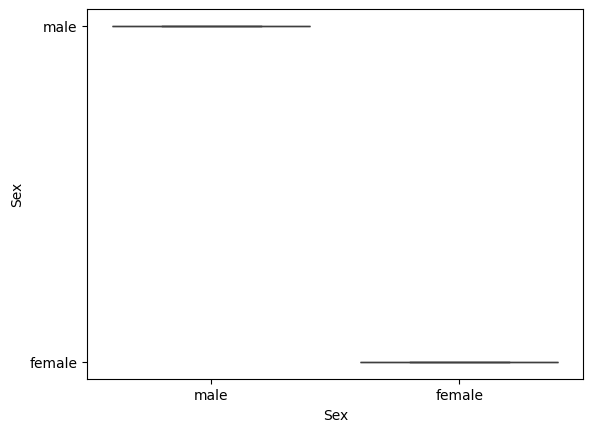

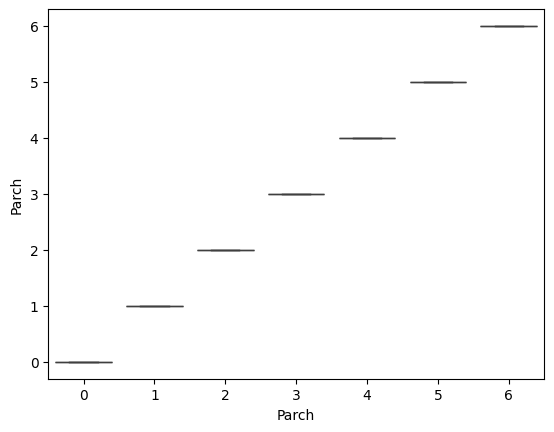

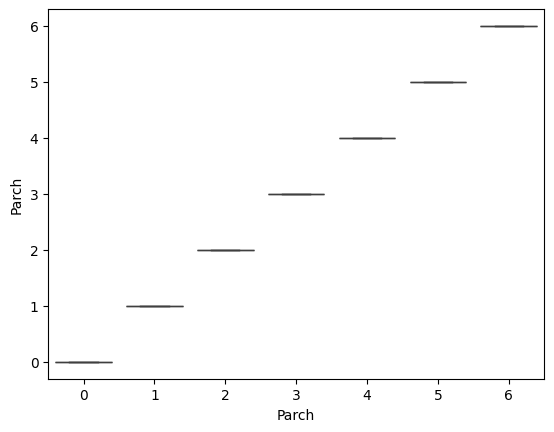

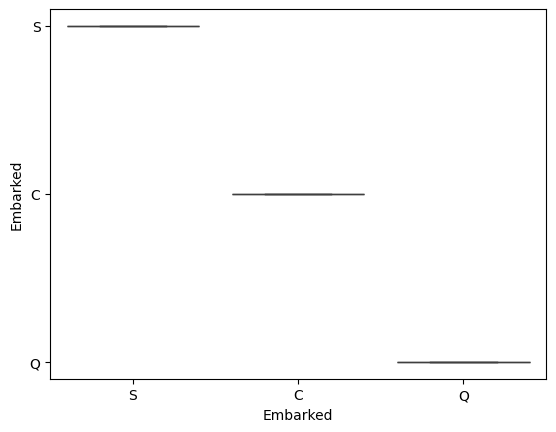

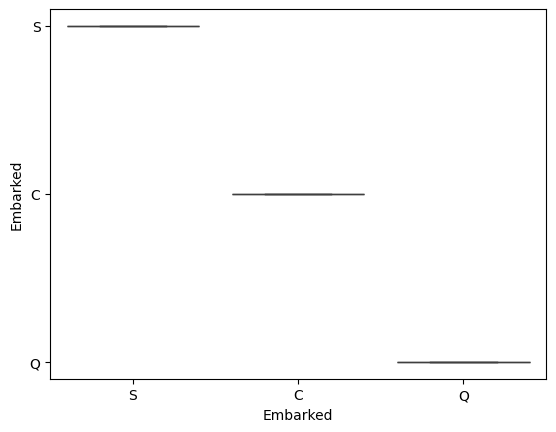

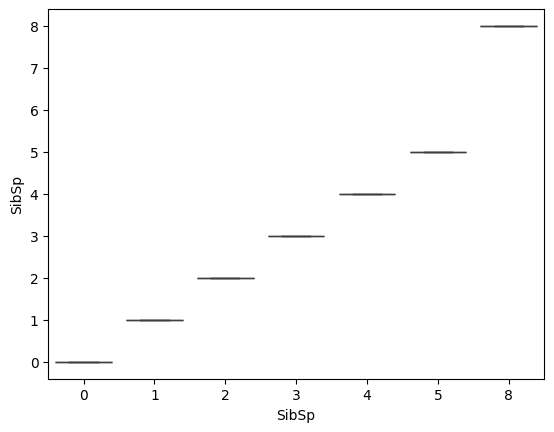

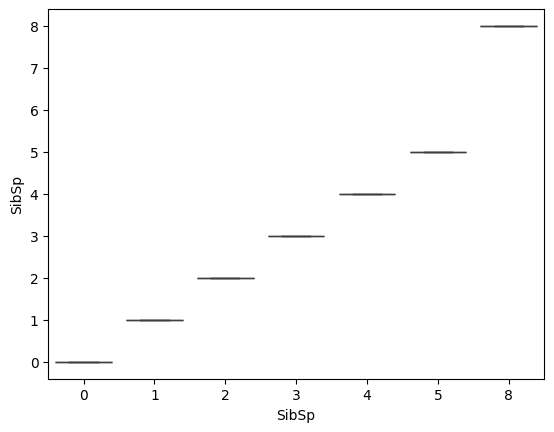

In [54]:
for col1 in cat_cols:
    for col2 in num_cols:
        sns.boxplot(x=df2[col1],y=df2[col1])
        plt.show()

# Multivariate Analysis

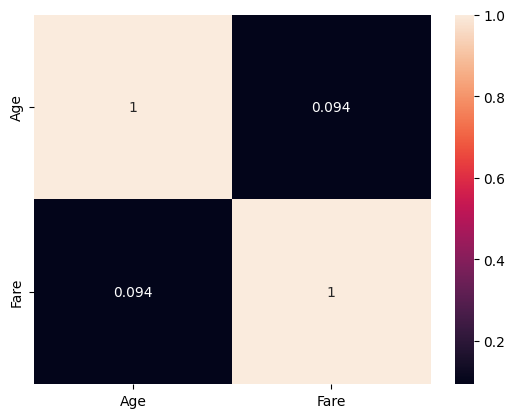

In [57]:
sns.heatmap(df2[num_cols].corr(),annot=True)
plt.show()

In [ ]:
## Correlation represents strength of relationship between variables
## Correlation lies in the range of -1 to 1
## Negative correlation (0 to -1) shows inverse relationship
## Positive correlation (0 to 1) shows direct relationship
## 0 correlation represents no relationship.


In [ ]:
# cat vs CAT (BIVARIATE)